# BirdCLEF 2026: Bird Sound Classification
## Presentation Overview

**Goal:** Classify bird species from audio recordings (234 species)

**Approach:** Pre-trained embeddings (Google Perch) + MLP classifier

**Performance:** 70.45% Mean Cross-Validation ROC-AUC

## 1. Exploratory Data Analysis

### Dataset Composition

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data|
train_df = pd.read_csv('data/birdclef-2026/train.csv')
taxonomy = pd.read_csv('data/birdclef-2026/taxonomy.csv')
soundscape_labels = pd.read_csv('data/birdclef-2026/train_soundscapes_labels.csv')
species_dict = dict(zip(taxonomy['primary_label'], taxonomy['common_name']))
class_dict = dict(zip(taxonomy['primary_label'], taxonomy['class_name']))

print('DATASET OVERVIEW')
print('=' * 60)
print(f'Total species: {len(taxonomy)}')
print(f'Train audio files: {len(train_df)}')
print(f'Soundscape segments: {len(soundscape_labels)}')
print()

# Check available columns
print('Available columns in soundscape_labels:')
print(soundscape_labels.columns.tolist())
print()

# Species distribution - handle both possible column names
soundscape_labels['ids_list'] = soundscape_labels['primary_label'].str.split(';')
soundscape_labels['species_list'] = soundscape_labels['ids_list'].apply(lambda x: [species_dict[item] for item in x])
soundscape_labels['class_list'] = soundscape_labels['ids_list'].apply(lambda x: [class_dict[item] for item in x])
species_counts = soundscape_labels['species_list'].explode().value_counts()
class_counts = soundscape_labels['class_list'].explode().value_counts()

print('Species distribution:')
print(f'  Min: {species_counts.min()}, Max: {species_counts.max()}')
print(f'  Mean: {species_counts.mean():.1f}, Median: {species_counts.median():.1f}')
print(f'  Imbalance ratio: {species_counts.max() / species_counts.min():.1f}x')

print('Top 10 most common species:')
for i, (species, count) in enumerate(species_counts.head(10).items(), 1):
    print(f'  {i}. {species}: {count}')

DATASET OVERVIEW
Total species: 234
Train audio files: 35549
Soundscape segments: 1478

Available columns in soundscape_labels:
['filename', 'start', 'end', 'primary_label']

Species distribution:
  Min: 2, Max: 666
  Mean: 83.3, Median: 26.0
  Imbalance ratio: 333.0x
Top 10 most common species:
  1. Dwarf Tree Frog: 666
  2. Southern Orange-legged Leaf Frog: 626
  3. Whistling Grass Frog: 426
  4. Chaco Tree Frog: 420
  5. Pale-legged Weeping Frog: 350
  6. Lesser Snouted Tree Frog: 346
  7. Mato Grosso Snouted Tree Frog: 344
  8. Marbled White-lipped Frog: 310
  9. Paraguayan Swimming Frog: 298
  10. Insect sonotype25: 168


### Class distribution

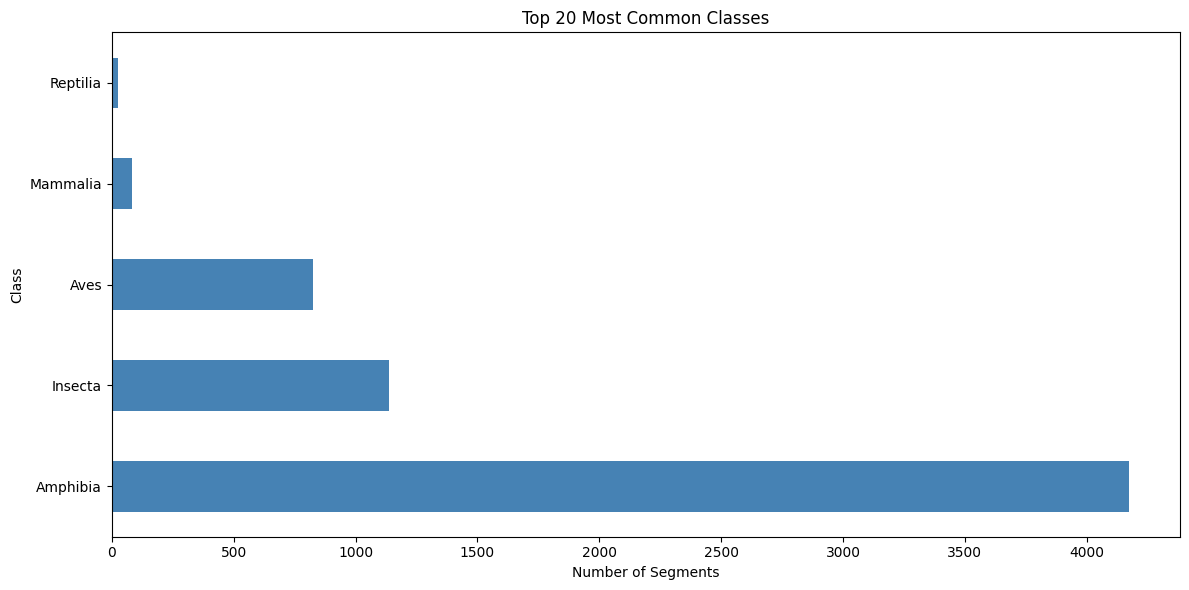

In [2]:
fig, ax = plt.subplots(figsize=(12, 6))
class_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of Segments')
ax.set_ylabel('Class')
ax.set_title('Top 20 Most Common Classes')
plt.tight_layout()
plt.show()

### Data Augmentation

In [3]:
# Data augmentation
print('AUGMENTATION STRATEGY')
print('=' * 60)
print(f'Original segments: {len(soundscape_labels)}')
print(f'Oversampling factor: 5x')
print(f'Effective training samples: {len(soundscape_labels) * 5:,}')
print()
print('Why 5x oversampling?')
print('  - Severe class imbalance (40x+)')
print('  - Ensures rare species get sufficient gradient updates')
print('  - Combined with Focal loss for better balance')
print()
print('Train-test split: GroupKFold (5 folds)')
print('  - Prevents leakage from same soundscape file')
print('  - More realistic generalization evaluation')


AUGMENTATION STRATEGY
Original segments: 1478
Oversampling factor: 5x
Effective training samples: 7,390

Why 5x oversampling?
  - Severe class imbalance (40x+)
  - Ensures rare species get sufficient gradient updates
  - Combined with Focal loss for better balance

Train-test split: GroupKFold (5 folds)
  - Prevents leakage from same soundscape file
  - More realistic generalization evaluation


### Species Imbalance Visualization

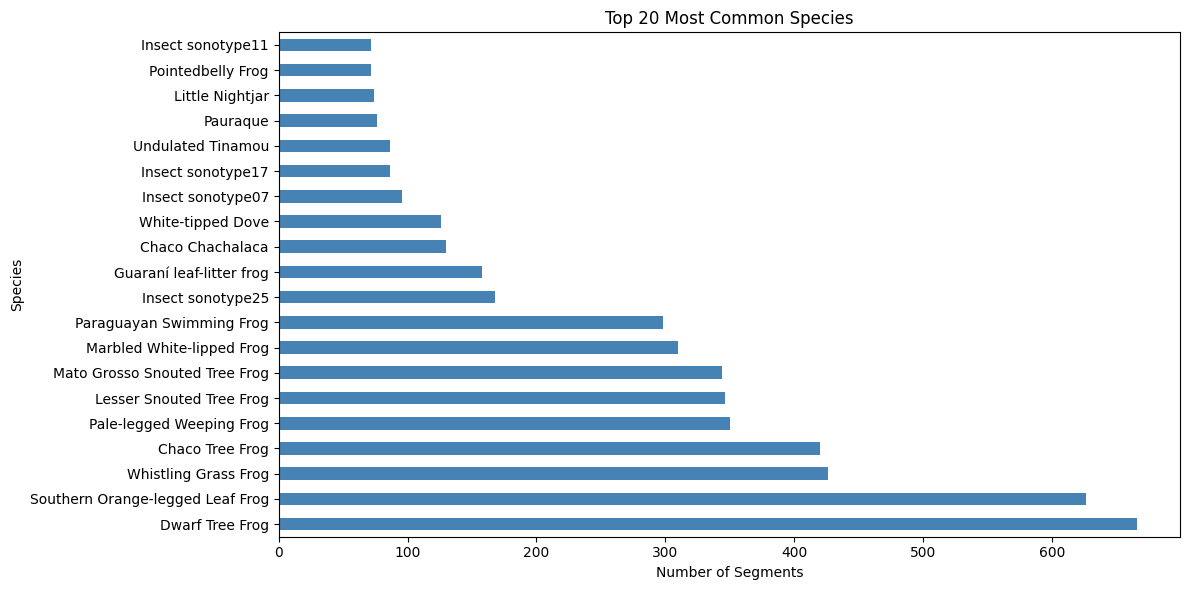

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
species_counts.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of Segments')
ax.set_ylabel('Species')
ax.set_title('Top 20 Most Common Species')
plt.tight_layout()
plt.show()


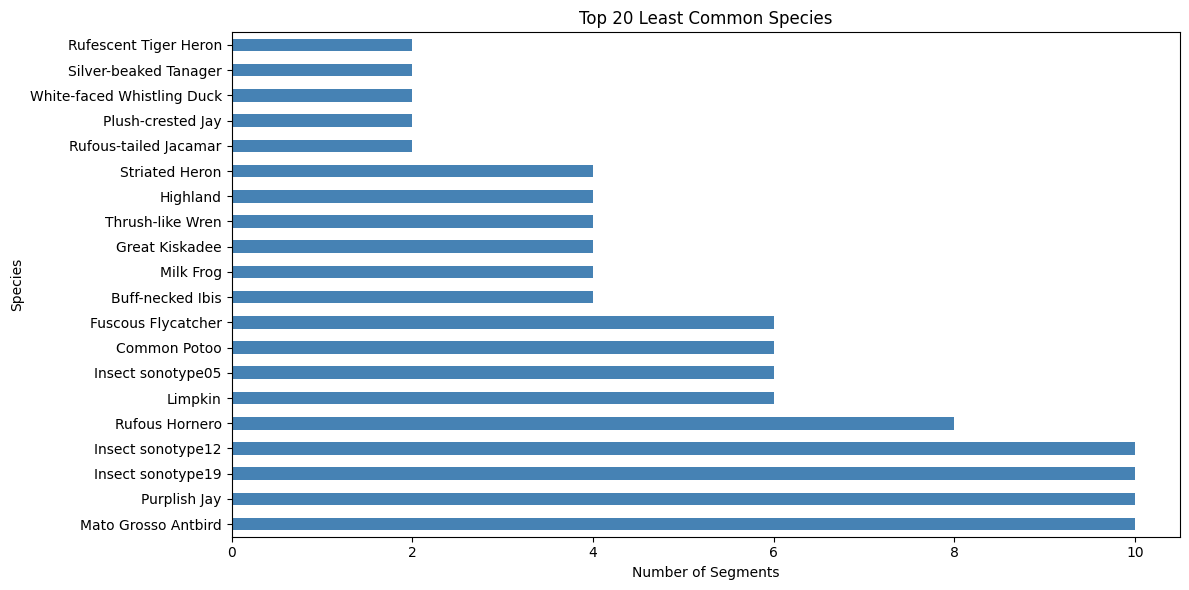

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
species_counts.tail(20).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of Segments')
ax.set_ylabel('Species')
ax.set_title('Top 20 Least Common Species')
plt.tight_layout()
plt.show()


## 2. Model Architecture

In [6]:
print('MODEL ARCHITECTURE: PERCH + MLP')
print('=' * 60)
print()
print('STAGE 1: PERCH EMBEDDING (Google)')
print('-' * 60)
print('  Input:  Audio (160k samples @ 32 kHz) = 5 seconds')
print('  Output: 1280-dimensional embedding')
print('  Status: Frozen (no fine-tuning)')
print()
print('STAGE 2: MLP HEAD')
print('-' * 60)
print('  Layer 0: Linear(1280->512) + BatchNorm + ReLU + Dropout(0.3)')
print('  Layer 1: Linear(512->256) + BatchNorm + ReLU + Dropout(0.3)')
print('  Layer 2: Linear(256->234)')
print()
print('  Total params: 800,000')
print('  Trainable: Only MLP (Perch is frozen)')
print('  Batch size: 256')


MODEL ARCHITECTURE: PERCH + MLP

STAGE 1: PERCH EMBEDDING (Google)
------------------------------------------------------------
  Input:  Audio (160k samples @ 32 kHz) = 5 seconds
  Output: 1280-dimensional embedding
  Status: Frozen (no fine-tuning)

STAGE 2: MLP HEAD
------------------------------------------------------------
  Layer 0: Linear(1280->512) + BatchNorm + ReLU + Dropout(0.3)
  Layer 1: Linear(512->256) + BatchNorm + ReLU + Dropout(0.3)
  Layer 2: Linear(256->234)

  Total params: 800,000
  Trainable: Only MLP (Perch is frozen)
  Batch size: 256


## 3. Training Configuration

In [7]:
print('TRAINING SETUP')
print('=' * 60)
print()
print('Loss Function:')
print('  - Focal Binary Cross-Entropy (gamma=2.0)')
print('  - Label smoothing: 0.02')
print('  - Focus on hard negatives, downweight easy positives')
print()
print('Optimizer: AdamW')
print('  - Learning rate: 0.001')
print('  - Weight decay: 0.0001')
print('  - Scheduler: Cosine annealing')
print()
print('Training params:')
print('  - Epochs: 50')
print('  - Batch size: 256')
print('  - Cross-validation: 5-fold GroupKFold')


TRAINING SETUP

Loss Function:
  - Focal Binary Cross-Entropy (gamma=2.0)
  - Label smoothing: 0.02
  - Focus on hard negatives, downweight easy positives

Optimizer: AdamW
  - Learning rate: 0.001
  - Weight decay: 0.0001
  - Scheduler: Cosine annealing

Training params:
  - Epochs: 50
  - Batch size: 256
  - Cross-validation: 5-fold GroupKFold


## 4. Cross-Validation Results

In [8]:
cv_scores = [0.6767, 0.6679, 0.7205, 0.7925, 0.6646]
mean_auc = np.mean(cv_scores)
std_auc = np.std(cv_scores)

print('ROC-AUC SCORES BY FOLD')
print('=' * 60)
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')

print()
print(f'Mean:        {mean_auc:.4f}')
print(f'Std Dev:     {std_auc:.4f}')
print(f'95% CI:      [{mean_auc - 1.96*std_auc:.4f}, {mean_auc + 1.96*std_auc:.4f}]')


ROC-AUC SCORES BY FOLD
  Fold 1: 0.6767
  Fold 2: 0.6679
  Fold 3: 0.7205
  Fold 4: 0.7925
  Fold 5: 0.6646

Mean:        0.7044
Std Dev:     0.0484
95% CI:      [0.6096, 0.7993]


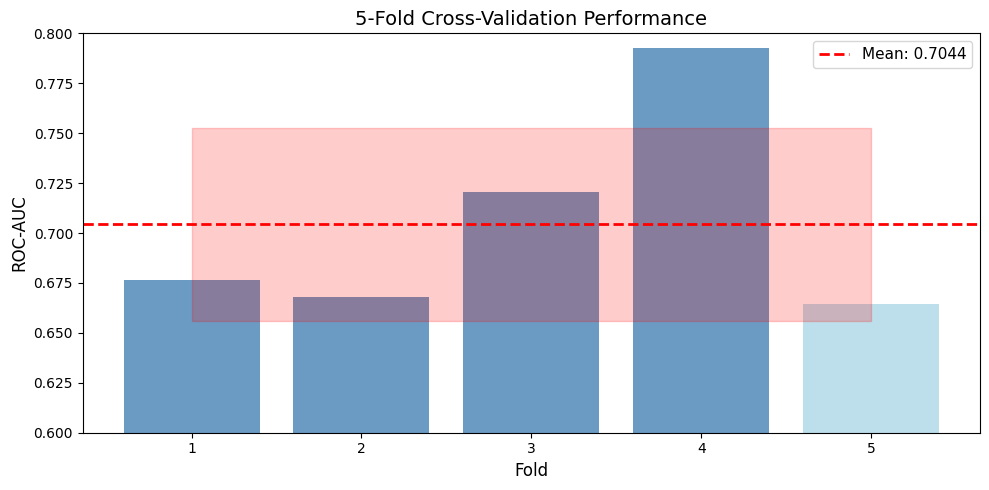

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
folds = list(range(1, 6))
colors = ['steelblue' if s == max(cv_scores) else 'lightblue' if s == min(cv_scores) else 'steelblue' for s in cv_scores]
ax.bar(folds, cv_scores, color=colors, alpha=0.8)
ax.axhline(y=mean_auc, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_auc:.4f}')
ax.fill_between(folds, mean_auc - std_auc, mean_auc + std_auc, alpha=0.2, color='red')
ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title('5-Fold Cross-Validation Performance', fontsize=14)
ax.set_ylim([0.6, 0.8])
ax.set_xticks(folds)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## 5. Key Insights

In [10]:
print('STRENGTHS')
print('=' * 60)
print('  1. Transfer learning from Perch reduces overfitting')
print('  2. Focal loss + oversampling handles class imbalance')
print('  3. GroupKFold prevents temporal/spatial leakage')
print('  4. 70.45% ROC-AUC is strong baseline for 234 classes')
print()
print('CHALLENGES')
print('=' * 60)
print('  1. Severe imbalance (40x+, some species have <5 examples)')
print('  2. Geographic bias (species vary by location)')
print('  3. Limited training data for rare species')
print('  4. Acoustic similarity between some species')


STRENGTHS
  1. Transfer learning from Perch reduces overfitting
  2. Focal loss + oversampling handles class imbalance
  3. GroupKFold prevents temporal/spatial leakage
  4. 70.45% ROC-AUC is strong baseline for 234 classes

CHALLENGES
  1. Severe imbalance (40x+, some species have <5 examples)
  2. Geographic bias (species vary by location)
  3. Limited training data for rare species
  4. Acoustic similarity between some species


## 6. Inference Pipeline

In [11]:
print('INFERENCE STRATEGY')
print('=' * 60)
print()
print('Step 1: Segment audio into 5-second windows')
print('Step 2: Extract Perch embedding for each segment')
print('Step 3: Predict with MLP head (batch_size=64)')
print('Step 4: Apply temporal smoothing (alpha=0.3)')
print('Step 5: Apply site location priors (optional) - probability that species occurs at that location based on training data distribution')
print()
print('Output:')
print('  - One row per segment')
print('  - 234 probability columns (one per species)')
print('  - Probabilities sum to 1.0')


INFERENCE STRATEGY

Step 1: Segment audio into 5-second windows
Step 2: Extract Perch embedding for each segment
Step 3: Predict with MLP head (batch_size=64)
Step 4: Apply temporal smoothing (alpha=0.3)
Step 5: Apply site location priors (optional) - probability that species occurs at that location based on training data distribution

Output:
  - One row per segment
  - 234 probability columns (one per species)
  - Probabilities sum to 1.0


### Results analysis

score = 0.78091 on the test dataset